## Objectif

Réalisé un premier fine-tuning supervisé exploratoire du modèle `Qwen/Qwen3-1.7B-Base` avec LoRA.

L'objectif n'est pas d'obtenir le meilleur modèle final, mais de valider la pipeline technique :

- chargement du modèle et du tokenizer ;
- chargement des datasets SFT ;
- tokenisation correcte ;
- masquage du prompt dans les labels ;
- entraînement LoRA sur GPU ;
- génération de checkpoints ;
- suivi des pertes d'entraînement et de validation ;
- premier test qualitatif sur un cas clinique critique.

Ce run utilise un faible nombre d'époques afin de limiter le coût GPU et de détecter rapidement les erreurs de pipeline.

In [38]:
import os
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
)
from peft import LoraConfig, get_peft_model

In [39]:
MODEL_NAME = "Qwen/Qwen3-1.7B-Base"

DATA_DIR = "../../data"
OUTPUT_DIR = "../../outputs/qwen3-sft-run-test"

SEED = 42
MAX_LENGTH = 1024

### Vérification GPU

In [40]:
print("Torch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("Mémoire GPU totale :", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

Torch : 2.5.1+cu121
CUDA disponible : True
GPU : NVIDIA GeForce RTX 4060 Laptop GPU
Mémoire GPU totale : 8.0 GB


## Chargement du tokenizer

Le tokenizer associé au modèle `Qwen/Qwen3-1.7B-Base` est chargé depuis Hugging Face.

Il permet de convertir les textes médicaux en tokens utilisables par le modèle.  
Le token de padding est aligné sur le token de fin de séquence afin de permettre le padding dynamique pendant l'entraînement.

In [41]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer chargé")
print("Pad token :", tokenizer.pad_token)
print("EOS token :", tokenizer.eos_token)

Tokenizer chargé
Pad token : <|endoftext|>
EOS token : <|endoftext|>


## Chargement du modèle de base

In [42]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)

model.config.use_cache = False

print("Modèle chargé")
print("Device principal :", next(model.parameters()).device)

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 368.08it/s]


Modèle chargé
Device principal : cuda:0


## Configuration LoRA

LoRA permet d'adapter le modèle sans réentraîner l'ensemble de ses paramètres.

Seules de petites matrices entraînables sont ajoutées sur certaines couches d'attention du modèle.  
Cela réduit fortement l'empreinte GPU, ce qui est adapté à un run de test sur une carte de 8 GB.

In [43]:
lora_config = LoraConfig(
    r=8, #taille des matrices LoRA, petit pour limiter la mémoire
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"], #on adapte seulement une partie de l’attention.
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,605,632 || all params: 1,722,180,608 || trainable%: 0.0932


## Chargement des datasets SFT

In [44]:
train_dataset = load_dataset(
    "json",
    data_files=f"{DATA_DIR}/sft_train.jsonl",
    split="train"
)

val_dataset = load_dataset(
    "json",
    data_files=f"{DATA_DIR}/sft_validation.jsonl",
    split="train"
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print(train_dataset[0])

Train : 4775
Validation : 618
{'instruction': 'Monsieur D., 77 ans, est hospitalisé à la demande de son médecin traitant pour\nconfusion aiguë.\nDans ses antécédents, figurent un infarctus du myocarde (qu’il a présenté il y a 10\nans), une artériopathie oblitérante des membres inférieurs, une hypertension\nartérielle et un diabète depuis 20 ans devenu insulino requérant depuis 10 ans.\nC’était un gros fumeur, sevré depuis une dizaine d’années.\nSon traitement habituel est le suivant :\n\nUMULINE® NPH (16 U le matin, 16 U le soir)\nACTOS® 15 (pioglitazone) : 1cp/j\nELISOR® 40 (pravastatine) : 1cp/j\nLASILIX® FAIBLE 20 mg (furosémide) : 1cp/j\nRENITEC® 20 (énalapril) : 1cp/j\nPLAVIX® 75 (clopidogrel) : 1cp/j\nNITRIDERM TTS® 5 mg (trinitrine) : 1/j\n\nA l’examen clinique d’entrée il est confus, très dyspnéique, encombré. Il présente de\ndiscrets oedèmes remontant jusqu’aux cuisses, sans reflux hépatojugulaire. La toux\nramène une expectoration mousseuse. Il pré

## Mise au format conversationnel

Chaque exemple SFT est converti au format de conversation attendu par Qwen.

Le prompt contient le rôle `user`, puis la réponse attendue est placée dans le rôle `assistant`.  
Ce format permet au modèle d'apprendre à produire une réponse assistant à partir d'une instruction médicale.

In [45]:
def build_prompt(example):
    return (
        "<|im_start|>user\n"
        + example["instruction"].strip()
        + "\n<|im_end|>\n"
        + "<|im_start|>assistant\n"
    )

def build_full_text(example):
    return (
        build_prompt(example)
        + example["response"].strip()
        + "\n<|im_end|>"
    )

print(build_full_text(train_dataset[0]))

<|im_start|>user
Monsieur D., 77 ans, est hospitalisé à la demande de son médecin traitant pour
confusion aiguë.
Dans ses antécédents, figurent un infarctus du myocarde (qu’il a présenté il y a 10
ans), une artériopathie oblitérante des membres inférieurs, une hypertension
artérielle et un diabète depuis 20 ans devenu insulino requérant depuis 10 ans.
C’était un gros fumeur, sevré depuis une dizaine d’années.
Son traitement habituel est le suivant :

UMULINE® NPH (16 U le matin, 16 U le soir)
ACTOS® 15 (pioglitazone) : 1cp/j
ELISOR® 40 (pravastatine) : 1cp/j
LASILIX® FAIBLE 20 mg (furosémide) : 1cp/j
RENITEC® 20 (énalapril) : 1cp/j
PLAVIX® 75 (clopidogrel) : 1cp/j
NITRIDERM TTS® 5 mg (trinitrine) : 1/j

A l’examen clinique d’entrée il est confus, très dyspnéique, encombré. Il présente de
discrets oedèmes remontant jusqu’aux cuisses, sans reflux hépatojugulaire. La toux
ramène une expectoration mousseuse. Il présente une fièvre à 38°2.
Les examens biologiqu

## Tokenisation et masquage du prompt

Les exemples sont tokenisés en distinguant deux parties :

- le prompt utilisateur ;
- la réponse assistant attendue.

Dans les labels, les tokens du prompt sont remplacés par `-100`.  
Cette valeur indique à PyTorch d'ignorer cette partie dans le calcul de la loss.

Ainsi, le modèle est entraîné à prédire uniquement la réponse assistant, et non à recopier l'instruction utilisateur.

In [46]:
def tokenize_function(example):
    prompt_text = build_prompt(example)
    full_text = build_full_text(example)

    tokenized_full = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    )

    tokenized_prompt = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    )

    input_ids = tokenized_full["input_ids"]
    attention_mask = tokenized_full["attention_mask"]

    labels = input_ids.copy()

    prompt_length = len(tokenized_prompt["input_ids"])
    prompt_length = min(prompt_length, len(labels))

    labels[:prompt_length] = [-100] * prompt_length

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

In [47]:
tokenized_example = tokenize_function(train_dataset[0])

print("Longueur input_ids :", len(tokenized_example["input_ids"]))
print("Longueur labels :", len(tokenized_example["labels"]))
print("Nombre de labels masqués :", sum(1 for x in tokenized_example["labels"] if x == -100))
print("Nombre de labels entraînés :", sum(1 for x in tokenized_example["labels"] if x != -100))

Longueur input_ids : 762
Longueur labels : 762
Nombre de labels masqués : 539
Nombre de labels entraînés : 223


## Application de la tokenisation aux datasets

La fonction de tokenisation est appliquée aux jeux d'entraînement et de validation.

Les colonnes textuelles originales sont retirées après tokenisation afin de conserver uniquement les champs nécessaires à l'entraînement :
- `input_ids` ;
- `attention_mask` ;
- `labels`.

In [48]:
tokenized_train = train_dataset.map(
    tokenize_function,
    remove_columns=train_dataset.column_names
)

tokenized_val = val_dataset.map(
    tokenize_function,
    remove_columns=val_dataset.column_names
)

print(tokenized_train)
print(tokenized_val)
print(tokenized_train.features)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4775
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 618
})
{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


## Analyse des longueurs tokenisées

Une analyse des longueurs permet de vérifier que la limite `MAX_LENGTH=1024` est adaptée au dataset.

L'objectif est de limiter la consommation GPU tout en évitant de tronquer une proportion trop importante d'exemples.

In [49]:
import numpy as np

train_lengths = np.array([len(example["input_ids"]) for example in tokenized_train])

print("Nombre d'exemples :", len(train_lengths))
print("Longueur moyenne :", round(train_lengths.mean(), 2))
print("Longueur médiane :", np.median(train_lengths))
print("Longueur max après troncature :", train_lengths.max())
print("> 512 tokens :", (train_lengths > 512).sum(), f"({(train_lengths > 512).mean() * 100:.2f}%)")
print("> 768 tokens :", (train_lengths > 768).sum(), f"({(train_lengths > 768).mean() * 100:.2f}%)")
print("= 1024 tokens :", (train_lengths == MAX_LENGTH).sum(), f"({(train_lengths == MAX_LENGTH).mean() * 100:.2f}%)")

Nombre d'exemples : 4775
Longueur moyenne : 330.95
Longueur médiane : 297.0
Longueur max après troncature : 1024
> 512 tokens : 1024 (21.45%)
> 768 tokens : 215 (4.50%)
= 1024 tokens : 39 (0.82%)


La longueur maximale de 1024 tokens est conservée pour le run de test.

Seuls 39 exemples, soit 0,82 % du train set, atteignent la limite maximale et sont donc potentiellement tronqués.  
Ce compromis est acceptable pour un premier run LoRA sur un GPU de 8 GB.

## Data collator

Le data collator prépare les batchs pendant l'entraînement.

Il applique un padding dynamique : les exemples sont complétés à la longueur du plus long exemple du batch, et non à une longueur fixe globale.  
Cela limite la mémoire utilisée sur GPU.

In [50]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True
)

print("Data collator prêt")

Data collator prêt


## Configuration de l'entraînement de test

Ce premier run sert à valider la pipeline SFT LoRA avant un entraînement plus long.

Les hyperparamètres sont volontairement prudents afin de limiter l'utilisation GPU :
- 1 époch ;
- batch size réduit ;
- checkpoints réguliers ;
- évaluation sur le jeu de validation ;
- graine fixe pour la reproductibilité.

In [51]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=1,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=2,

    learning_rate=2e-4,
    weight_decay=0.0,
    warmup_ratio=0.03,
    lr_scheduler_type="linear",

    eval_strategy="steps",
    eval_steps=250,

    save_strategy="steps",
    save_steps=250,
    save_total_limit=3,

    logging_steps=25,

    fp16=torch.cuda.is_available(),

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",

    seed=SEED,
    data_seed=SEED,

    remove_unused_columns=False,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## Création du Trainer

Le `Trainer` de Hugging Face orchestre l'entraînement :

- modèle LoRA ;
- arguments d'entraînement ;
- dataset d'entraînement ;
- dataset de validation ;
- data collator pour le padding dynamique.

## Filtrage des exemples sans labels entraînables

Certains exemples trop longs sont tronqués avant la réponse assistant.  
Dans ce cas, ils ne contiennent aucun token de réponse à apprendre, ce qui peut provoquer une `eval_loss` égale à `nan`.

Ces exemples sont retirés avant l'entraînement.

In [52]:
def has_trainable_labels(example):
    return any(label != -100 for label in example["labels"])

print("Avant filtrage train :", len(tokenized_train))
print("Avant filtrage validation :", len(tokenized_val))

tokenized_train = tokenized_train.filter(has_trainable_labels)
tokenized_val = tokenized_val.filter(has_trainable_labels)

print("Après filtrage train :", len(tokenized_train))
print("Après filtrage validation :", len(tokenized_val))

Avant filtrage train : 4775
Avant filtrage validation : 618
Après filtrage train : 4762
Après filtrage validation : 617


In [53]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)

print("Trainer créé")

Trainer créé


In [54]:
print("Nombre d'exemples train :", len(tokenized_train))
print("Nombre d'exemples validation :", len(tokenized_val))
print("Dossier de sortie :", OUTPUT_DIR)

Nombre d'exemples train : 4762
Nombre d'exemples validation : 617
Dossier de sortie : ../../outputs/qwen3-sft-run-test


## Lancement du run SFT LoRA de test

Le fine-tuning est lancé pour une seule époch.

Ce run permet de vérifier :
- que la loss diminue ;
- que la validation s'exécute correctement ;
- que les checkpoints sont sauvegardés ;
- que l'entraînement peut être repris si nécessaire.

In [18]:
train_result = trainer.train()

train_result

Step,Training Loss,Validation Loss
250,2.201128,2.416115
500,2.249804,2.369613
750,2.121489,2.331697
1000,2.114992,2.318875
1250,2.126794,2.293483
1500,2.032426,2.290031
1750,2.000018,2.279847
2000,2.280120,2.273995
2250,1.856387,2.268696
2381,1.933180,2.267159


TrainOutput(global_step=2381, training_loss=2.132457947841165, metrics={'train_runtime': 9218.0526, 'train_samples_per_second': 0.517, 'train_steps_per_second': 0.258, 'total_flos': 1.32660731100672e+16, 'train_loss': 2.132457947841165, 'epoch': 1.0})

In [55]:
eval_metrics = trainer.evaluate()
eval_metrics

Training Loss,Validation Loss,Step
No log,3.041337,0


{'eval_loss': 3.041337251663208}

In [56]:
def count_trainable_labels(dataset):
    counts = []

    for example in dataset:
        n_trainable = sum(1 for label in example["labels"] if label != -100)
        counts.append(n_trainable)

    return counts

train_label_counts = count_trainable_labels(tokenized_train)
val_label_counts = count_trainable_labels(tokenized_val)

print("Train exemples sans label entraînable :", sum(c == 0 for c in train_label_counts))
print("Validation exemples sans label entraînable :", sum(c == 0 for c in val_label_counts))

print("Min labels entraînables train :", min(train_label_counts))
print("Min labels entraînables validation :", min(val_label_counts))

Train exemples sans label entraînable : 0
Validation exemples sans label entraînable : 0
Min labels entraînables train : 1
Min labels entraînables validation : 3


## Test qualitatif de génération

Un premier test qualitatif est réalisé sur un cas clinique critique non issu directement du dataset.

L'objectif est de vérifier si le modèle adopte une conduite prudente face à une situation d'urgence potentielle.

In [23]:
def generate_answer(prompt, max_new_tokens=100):
    model.eval()

    inputs = tokenizer(
        "<|im_start|>user\n"
        + prompt.strip()
        + "\n<|im_end|>\n"
        + "<|im_start|>assistant\n",
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

In [24]:
prompt = """
Tu es un assistant de triage médical.
Tu ne poses pas de diagnostic définitif.
Tu ne prescris pas de traitement médicamenteux.
Tu aides uniquement à estimer le niveau d'urgence et à recommander une conduite prudente.

Patient de 62 ans avec douleur thoracique brutale, essoufflement et sueurs.

Réponds en français, en exactement 4 lignes, avec ce format :
Priorité :
Raison :
Conduite à tenir :
Limite :
"""

response = generate_answer(prompt, max_new_tokens=160)
print(response)

- Urgence : 
- Raisons : 
 - Douleur thoraco-brachiale (syndrome angina) ou pneumothorax.  
 - Conduite a tenir : 
   - Restez chez vous si la douleur persiste après 15 minutes. 
   Si elle s’aggrave, rendez-vous au plus vite dans l’hôpital. 
 - Limite : 
    - Pas de prise de sang ni d’échographie cardiaque avant consultation du médecin.
 - Autres conseils : 
     - Ne prenez aucun médicament sans avis médical. 
     Il faut attendre que votre médecin soit là pour prendre des décisions sur les traitements appropriés.
 - Attention aux signes de détresse


## Sauvegarde du checkpoint de test

Le checkpoint est sauvegardé comme baseline technique.

Il ne constitue pas un modèle cliniquement validé, mais permet de conserver une trace du premier run SFT LoRA fonctionnel.

In [25]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Checkpoint de test sauvegardé dans :", OUTPUT_DIR)

Checkpoint de test sauvegardé dans : ../../outputs/qwen3-sft-run-test


## Suivi graphique des métriques

Les métriques enregistrées par le `Trainer` sont utilisées pour tracer l'évolution de la loss pendant l'entraînement.

Ce suivi permet de documenter la convergence du run et de répondre à l'exigence de traçabilité des métriques.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

logs_df = pd.DataFrame(trainer.state.log_history)

logs_df.tail()

""


In [57]:
import json
import pandas as pd
import matplotlib.pyplot as plt

trainer_state_path = "../../outputs/qwen3-sft-run-test/checkpoint-2381/trainer_state.json"

with open(trainer_state_path, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

logs_df = pd.DataFrame(trainer_state["log_history"])

logs_df.tail()

,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
100,0.965981,1.309224,7.189259e-06,2.047004,2300,NaN,NaN,NaN,NaN
101,0.976480,3.398002,5.023820e-06,2.298749,2325,NaN,NaN,NaN,NaN
102,0.986980,1.447328,2.858380e-06,2.069589,2350,NaN,NaN,NaN,NaN
103,0.997480,1.713706,6.929407e-07,1.933180,2375,NaN,NaN,NaN,NaN
104,1.000000,NaN,NaN,NaN,2381,2.267159,179.8235,3.431,3.431


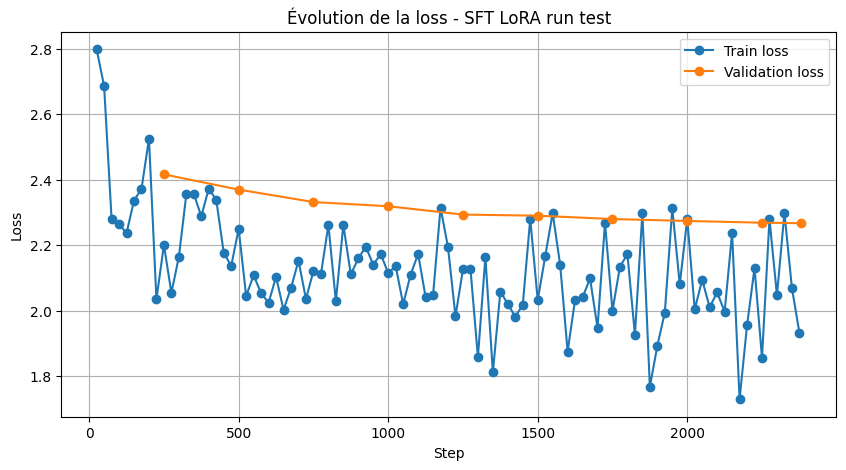

In [58]:
train_logs = logs_df[logs_df["loss"].notna()]
eval_logs = logs_df[logs_df["eval_loss"].notna()]

plt.figure(figsize=(10, 5))

plt.plot(train_logs["step"], train_logs["loss"], label="Train loss", marker="o")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation loss", marker="o")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Évolution de la loss - SFT LoRA run test")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
logs_path = "../../outputs/qwen3-sft-run-test/training_logs.csv"
logs_df.to_csv(logs_path, index=False)

print("Logs sauvegardés :", logs_path)

Logs sauvegardés : ../../outputs/qwen3-sft-run-test/training_logs.csv


### Interprétation des métriques

La train loss diminue globalement au cours du run, malgré des variations liées au faible batch size utilisé pour limiter la mémoire GPU.

La validation loss diminue également, passant d'environ 2.42 à 2.27.  
Cela indique que le modèle améliore sa capacité à prédire les réponses attendues sur le jeu de validation.

L'écart entre train loss et validation loss reste modéré sur ce run exploratoire d'une époque. Aucun signe évident de sur-apprentissage n'est observé à ce stade.

Ces métriques valident la convergence technique du run SFT LoRA, mais elles ne suffisent pas à valider la sécurité clinique du modèle. Les tests qualitatifs ont montré que le modèle peut encore produire des recommandations dangereuses sur des cas critiques.